In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as py
import seaborn as sns
from sklearn.cluster import KMeans

# Set style for plots
sns.set_style('whitegrid')

In [2]:
# Load the dataset
dataset = pd.read_csv('Mall_Customers.csv')
dataset.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
x=dataset.iloc[:, [3, 4]].values

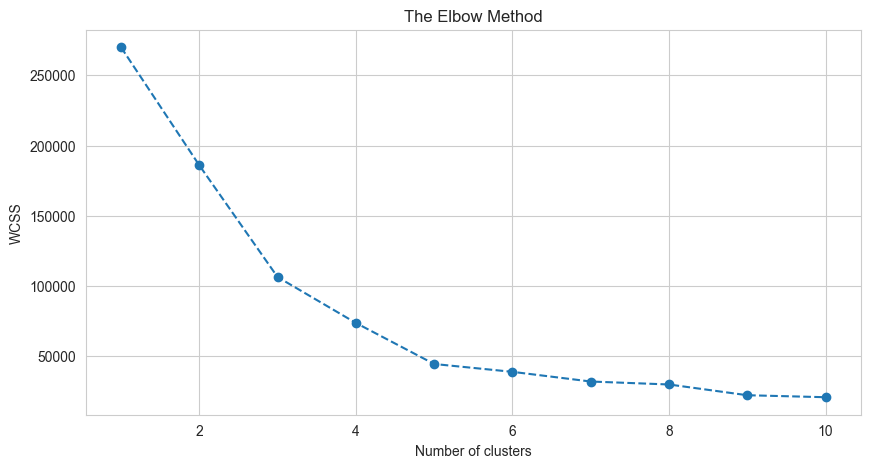

In [6]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=0)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

py.figure(figsize=(10, 5))
py.plot(range(1, 11), wcss,marker='o',linestyle='--')
py.title("The Elbow Method")
py.xlabel("Number of clusters")
py.ylabel("WCSS")
py.show()

In [ ]:
kmeans=KMeans(n_clusters=5,init='k-means++',random_state=42,n_init=10)
y_kmeans=kmeans.fit_predict(x)

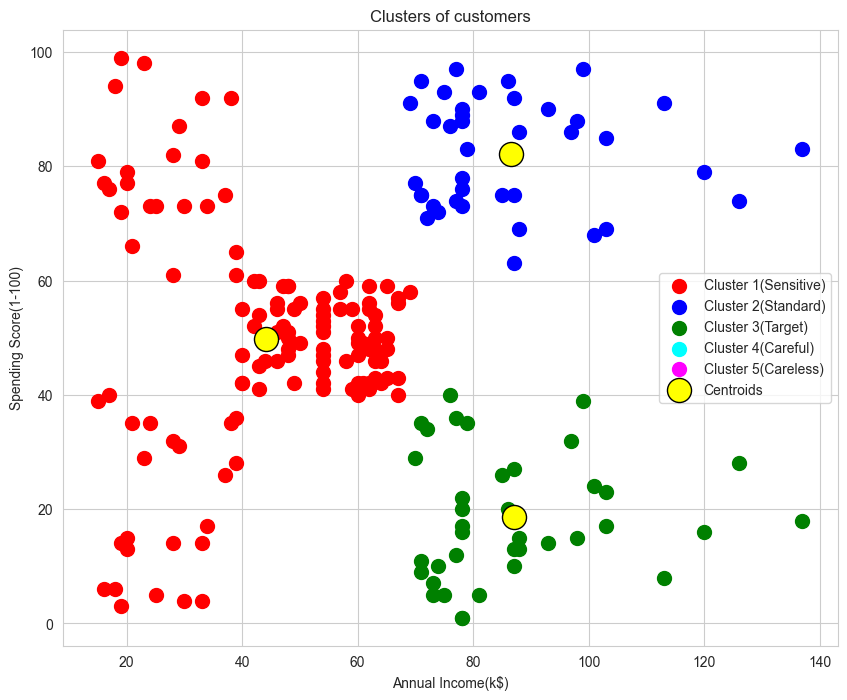

In [ ]:
py.figure(figsize=(10,8))
py.scatter(x[y_kmeans==0,0],x[y_kmeans==0,1],s=100,c='red',label='Cluster 1(Sensitive)')
py.scatter(x[y_kmeans==1,0],x[y_kmeans==1,1],s=100,c='blue',label='Cluster 2(Standard)')
py.scatter(x[y_kmeans==2,0],x[y_kmeans==2,1],s=100,c='green',label='Cluster 3(Target)')
py.scatter(x[y_kmeans==3,0],x[y_kmeans==3,1],s=100,c='cyan',label='Cluster 4(Careful)')
py.scatter(x[y_kmeans==4,0],x[y_kmeans==4,1],s=100,c='magenta',label='Cluster 5(Careless)')

py.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=300,c='yellow',label='Centroids',edgecolor='black')
py.title('Clusters of customers')
py.xlabel('Annual Income(k$)')
py.ylabel('Spending Score(1-100)')
py.legend()
py.show()

In [ ]:
def classify_customer():
    try:
        print(("---Market Segmentation Tool---"))
        income=int(input("Enter Annual Income in k$ (e.g., 80):"))
        spending=int(input("Enter Spending Score 1-100 (e.g., 20):"))

        # Predict data
        cluster =kmeans.predict([[income, spending]])[0]
        
        # Descriptive names for clusters based on visualization
        cluster_names = {
            0:"Sensitive (High Income, Low Spending)",
            1:"Standard (Average Income, Average Spending)",
            2:"Target (High Income, High Spending)",
            3:"Careful (Low Income, High Spending)",
            4:"Careless (Low Income, Low Spending)"
        }
        print("\n"+"="*30)
        print(f"Result: The customer belongs to Group{cluster +1}")
        print(f"Segnment: {cluster_names[cluster]}")
        print("="*40)

    except ValueError:
        print("Invalid input! Please enter numbers for income and spending score.")  
    
# Call the function
classify_customer() 

---Market Segmentation Tool---

Result: The customer belongs to Group3
Segnment: Target (High Income, High Spending)
